<div style="padding:28px;border-radius:18px;background:linear-gradient(135deg,#0f172a,#1e3a5f);color:white">
<div style="font-size:13px;letter-spacing:2px;font-weight:700">TUTORIAL OF AGENTIC SYSTEMS · ALGORITHMIC TRADING</div>
<h1 style="margin:8px 0 6px 0;font-size:34px">Notebook 04 — Build Self-Adapting Agent Systems</h1>
<div style="font-size:18px;opacity:.9">Capability discovery, team formation, and organizational reconfiguration</div></div>

### Introduction

Notebook 03 changed decisions while preserving the organization making them. Notebook 04 crosses a different boundary: the system can now change its own specialist team. This is the trading counterpart of an M&A system that discovers the capabilities required by an assignment, assembles an appropriate constellation, and reorganizes that constellation when the assignment changes.

The starting point is a capability requirement rather than a preassigned team label. An observed stress environment may require resilience and low-volatility analysis. Inflation pressure may require valuation and balance-sheet resilience. Another environment may call for trend analysis and fundamental assessment. These are explicit teaching policies derived from observable indicators, not privileged knowledge of the generator's hidden regime.

A catalog describes available agents, their capabilities, and a small resource cost. The formation mechanism searches combinations that cover the current requirements within a budget. Historical evidence can distinguish between feasible teams. An optional model call chooses among validated candidate plans, while deterministic validation remains responsible for coverage and resource limits. The model cannot invent a new executable tool or remove the review function.

Every plan records its members, required capabilities, added and removed agents, and communication dependencies. Reconfiguration therefore appears as a change in an inspectable organizational object. We can distinguish a revised ranking from a revised team and test both separately.

The system still operates as one investment organization. It does not yet discover independent peer constellations or negotiate external services. That interaction belongs to Notebook 05. Here the achievement is narrower and fundamental: organizational design becomes part of the system's operating process, subject to explicit constraints.

This notebook contains ten executable code units, each preceded by an explanation and a question for reflection. Run them in order and inspect their outputs before continuing. The supporting Python modules preserve earlier building blocks, while the new mechanisms are shown directly in the cells. All investment activity remains inside the synthetic simulation.

**Portfolio mandate:** five unique stocks, 20% per stock at each rebalance. **Model:** `gpt-5-nano` in optional live demonstrations. **Default:** deterministic teaching policy. **Separate download — no ZIP required.** Open this file in Colab. Run NB00 first, then NB01–NB05 in order. Code unit 1 creates the shared project folder and installs the embedded course modules. In Colab, authorize the Google Drive mount so all notebooks share their dataset and results. Use `LIVE_LLM=False` initially. For optional live calls, run `%pip install openai` in a temporary cell, add `OPENAI_API_KEY` to Colab Secrets, and enable notebook access. Historical example outputs are retained; rerun the cells to produce your own results.

<div style="padding:20px;border-left:6px solid #2563eb;background:#eff6ff;border-radius:10px;color:#0f172a"><b>What we need to understand and learn</b></div>

The new abstraction is a capability requirement. Instead of routing directly from a regime name to a favorite strategy, the system expresses the analytical functions needed for the current problem. This separates the reason for forming a team from the identity of the agents that happen to provide those functions. A requirement such as resilience can be covered by more than one specialist, while low_volatility currently has a narrower provider set.

The catalog makes discovery inspectable. Each entry includes an agent identifier, capability tags, and an integer resource cost. These costs represent teaching units of analytical capacity; they are not API prices or trading fees. Formation searches subsets of the catalog, checks coverage, and rejects combinations that exceed the budget. Among feasible alternatives, a utility rule considers observed trailing performance and a complexity penalty. No candidate may remove the mandatory control roles.

This is constrained organizational search. It is deliberately smaller than unrestricted self-modification. The system can form new combinations of registered capabilities, but it does not write arbitrary Python, invent new trading permissions, or train an entirely new strategy during a rebalance. Those extensions would require additional validation mechanisms. The present scope is enough to demonstrate that the operating team is no longer fixed in advance.

A plan is an explicit object with members and dependencies. Environment analysis precedes specialist work; specialists hand their results to the coordinator; review precedes execution. Comparing consecutive plans identifies added and removed members. This comparison is more informative than a label saying dynamic because it shows precisely which organizational change occurred and which requirement justified it.

The optional language-model path selects among candidate plans already shown to be feasible. The returned choice is executed through the same bounded tool adapter introduced in Notebook 01 and then validated again. The historical comparison uses the deterministic candidate ranking. This isolates the effect of organizational adaptation from variability in repeated model responses. Both approaches preserve a clear division between proposing an organizational choice and enforcing the limits under which that choice is permitted.

Consider an unavailable capability as an exercise in organizational reasoning. Removing the defensive catalog entry can make a low-volatility requirement infeasible. The correct response is an explicit failure or an authorized change to the catalog or mission, not a plan that quietly drops the requirement. This example shows why capability discovery must be accompanied by validation.

The resource budget also makes complexity visible. A larger team can cover more tags but incur more analytical cost, while a smaller team may be cheaper and more focused. The search expresses that tradeoff using a simple fixed penalty. These teaching coefficients should be treated as assumptions, not empirical estimates of an optimal organization.

When comparing plans, distinguish a new combination from a new capability. The system can produce team configurations that were not individually hard-coded as complete templates. However, every member still comes from a finite approved registry. That bounded form of self-adaptation is enough for the conceptual step and provides a clear foundation for discussing more ambitious forms of system modification later.

As you work, distinguish the object being observed, the function transforming it, the component authorized to act, and the evidence retained afterward. These distinctions recur throughout the ladder and make each additional level of organization easier to reason about.

### Code Unit 1 of 10 — Reuse the loop and its observed performance histories

The setup loads the shared market and the strategy histories saved by NB03. These histories support organizational choices, but the policy still slices them at each decision date. We do not replace the execution engine or create a new universe. The new layer concerns who participates in the work. This preserves the cumulative tutorial: observation tools, skills, review, accounting, and feedback remain available while team formation becomes a first-class operation.

**Expected observation.** The setup should find the baseline files written by NB03. Missing results indicate that the earlier loop has not been run or the bundle is incomplete. Reconfiguration should not silently replace those inputs with unrelated synthetic performance.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Why reuse the same accounting engine when evaluating reconfiguration?

In [ ]:
# @title
# Standalone download: supporting Python modules are embedded below. Run NB00 first.
from pathlib import Path
import sys, os, json, hashlib
from dataclasses import dataclass, field
from functools import lru_cache
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value): print(value)

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    ROOT = Path('/content/drive/MyDrive/Colab Notebooks/TOPIC_767 ALGORITHMIC_TRADING_AGENTIC_SYSTEMS')
else:
    ROOT = Path.cwd() / 'ALGORITHMIC_TRADING_AGENTIC_SYSTEMS'
ROOT.mkdir(parents=True, exist_ok=True)
# These readable source strings contain the same course modules used by the ZIP.
EMBEDDED_MODULES = {'__init__.py': '"""Transparent cumulative support code for NB00–NB05. See each module\'s matching notebook."""\n', 'adaptation.py': '"""NB04: capability discovery, constrained formation, and explicit reconfiguration."""\nfrom .loops import *\nfrom itertools import combinations\n\n@dataclass(frozen=True)\nclass Capability:\n    agent: str\n    tags: frozenset\n    cost: int\n\nCATALOG=[Capability(\'momentum\',frozenset([\'trend\',\'growth\']),2),\n         Capability(\'value\',frozenset([\'valuation\',\'recovery\']),2),\n         Capability(\'quality\',frozenset([\'resilience\',\'fundamentals\']),2),\n         Capability(\'defensive\',frozenset([\'resilience\',\'low_volatility\']),1),\n         Capability(\'reversion\',frozenset([\'reversal\',\'recovery\']),1)]\nMANDATORY=[\'environment\',\'coordinator\',\'review\',\'execution\']\n\ndef required_capabilities(environment):\n    if environment[\'estimate\']==\'stress\': return {\'resilience\',\'low_volatility\'}\n    if environment[\'estimate\']==\'inflation_pressure\': return {\'valuation\',\'resilience\'}\n    if environment[\'trend\']<0: return {\'recovery\',\'resilience\'}\n    return {\'trend\',\'fundamentals\'}\n\ndef discover_and_form(required,catalog=CATALOG,budget=5,scores=None):\n    scores=scores or {};candidates=[]\n    for n in range(1,len(catalog)+1):\n        for team in combinations(catalog,n):\n            tags=set().union(*(c.tags for c in team));cost=sum(c.cost for c in team)\n            if not required<=tags or cost>budget: continue\n            utility=sum(scores.get(c.agent,0) for c in team)/len(team)-.01*cost\n            candidates.append((utility,tuple(c.agent for c in team),cost))\n    if not candidates: raise ValueError(\'Capability request cannot be covered within budget.\')\n    candidates.sort(key=lambda x:(-x[0],x[2],x[1]))\n    return [{\'agents\':list(t),\'cost\':c,\'utility\':u} for u,t,c in candidates]\n\ndef validate_plan(plan,required,catalog=CATALOG,budget=5):\n    known={c.agent:c for c in catalog};names=plan[\'agents\']\n    if len(names)!=len(set(names)) or any(n not in known for n in names): raise ValueError(\'Invalid plan members.\')\n    tags=set().union(*(known[n].tags for n in names))\n    if not required<=tags or sum(known[n].cost for n in names)>budget: raise ValueError(\'Invalid plan coverage or cost.\')\n    if plan.get(\'mandatory\',MANDATORY)!=MANDATORY: raise ValueError(\'Control roles cannot be removed.\')\n    return True\n\ndef form_plan(view,asof,scores=None,previous=None,live=False,cache_dir=\'CACHE\'):\n    env=view.environment(asof);required=required_capabilities(env)\n    candidates=discover_and_form(required,scores=scores)\n    options={f\'plan_{i}\':p for i,p in enumerate(candidates)}\n    prompt_payload={\n        \'mission\':\'Choose one already-feasible specialist team for the observed conditions.\',\n        \'decision_rule\':\'Use the observed environment, required capabilities, trailing specialist scores, team cost, and unnecessary complexity. Do not assume plan_0 is best merely because it is listed first.\',\n        \'environment\':env,\n        \'required\':sorted(required),\n        \'trailing_scores\':scores or {},\n        \'previous_team\':list(previous or []),\n        \'candidates\':options\n    }\n    result=choose_with_model(json.dumps(prompt_payload,default=str),options,\n            lambda key:options[key],cache_dir,live,\'plan_0\')\n    plan=dict(result[\'result\']);plan[\'mandatory\']=MANDATORY.copy()\n    validate_plan(plan,required)\n    old=set(previous or []);new=set(plan[\'agents\'])\n    plan.update({\n        \'required\':sorted(required),\n        \'environment\':env,\n        \'added\':sorted(new-old),\n        \'removed\':sorted(old-new),\n        \'edges\':[[\'environment\',a] for a in plan[\'agents\']]\n                +[[a,\'coordinator\'] for a in plan[\'agents\']]\n                +[[\'coordinator\',\'review\'],[\'review\',\'execution\']],\n        \'mode\':result[\'mode\'],\n        \'selector_choice\':result.get(\'choice\'),\n        \'selector_explanation\':result.get(\'explanation\',\'\')\n    })\n    return plan\n\ndef adaptive_policy(view,shadow,live_mode=False,cache_dir=\'CACHE\'):\n    previous=[]\n    def policy(asof,context):\n        nonlocal previous\n        influence,scores=feedback_influence(shadow,asof)\n        plan=form_plan(view,asof,scores,previous,live=live_mode,cache_dir=cache_dir)\n        packet=run_constellation(view,asof,plan[\'agents\'],influence)\n        previous=plan[\'agents\']\n        label=\'reconfigured_team_llm\' if live_mode else \'reconfigured_team_deterministic\'\n        return packet[\'decision\'],{\'active\':previous.copy(),\'plan\':plan,\'policy\':label}\n    return policy\n\ndef topology_table(events):\n    return pd.DataFrame([{\'asof\':e[\'asof\'],\'active\':\', \'.join(e[\'active\']),\n        \'added\':\', \'.join(e.get(\'plan\',{}).get(\'added\',[])),\n        \'removed\':\', \'.join(e.get(\'plan\',{}).get(\'removed\',[])),\n        \'requirements\':\', \'.join(e.get(\'plan\',{}).get(\'required\',[]))} for e in events])\n', 'constellations.py': '"""NB02: fixed collaboration, independent review, next-close simulated execution."""\nfrom .primitives import *\n\n@dataclass\nclass ReviewAgent:\n    min_adv: float = 1_000_000\n    sector_cap: float = .6\n    def review(self, proposal, snapshot):\n        errors=[];w=proposal.get(\'weights\',{})\n        if len(w)!=5: errors.append(\'exactly_five_unique_stocks_required\')\n        if any(t not in snapshot.index for t in w): errors.append(\'unknown_stock\')\n        try:\n            if not all(np.isfinite(v) and abs(v-.2)<1e-10 for v in w.values()): errors.append(\'equal_weights_required\')\n            if abs(sum(w.values())-1)>1e-10: errors.append(\'fully_invested_required\')\n        except (TypeError,ValueError): errors.append(\'non_numeric_weight\')\n        if not errors:\n            sectors={}\n            for t,v in w.items():\n                s=snapshot.loc[t];sectors[s.sector]=sectors.get(s.sector,0)+v\n                if s.adv<self.min_adv: errors.append(\'insufficient_liquidity\')\n                if s.published_at>pd.Timestamp(proposal[\'asof\']): errors.append(\'future_fundamental\')\n                if s[\'asof\']!=pd.Timestamp(proposal[\'asof\']): errors.append(\'stale_snapshot\')\n            if max(sectors.values())>self.sector_cap+1e-10: errors.append(\'sector_concentration\')\n        digest=hashlib.sha256(json.dumps(proposal,sort_keys=True,default=str).encode()).hexdigest()\n        return {\'approved\':not errors,\'errors\':sorted(set(errors)),\'proposal_hash\':digest,\'role\':\'independent_review\'}\n\ndef integrate(proposals, snapshot, influence=None, sector_cap=.6):\n    if not proposals: raise ValueError(\'No specialist proposals.\')\n    influence=influence or {p[\'owner\']:1/len(proposals) for p in proposals}\n    total=sum(influence.get(p[\'owner\'],0) for p in proposals)\n    if total<=0: raise ValueError(\'No positive influence.\')\n    score=pd.Series(0.,index=snapshot.index)\n    for p in proposals:\n        if pd.Timestamp(p[\'asof\'])!=snapshot[\'asof\'].iloc[0]: raise ValueError(\'Mixed observation dates.\')\n        score+=pd.Series(p[\'ranking\']).reindex(score.index).fillna(0)*influence.get(p[\'owner\'],0)/total\n    order=pd.DataFrame({\'score\':score,\'ticker\':score.index})\n    order=order.rename_axis(None)\n    order=order.sort_values([\'score\',\'ticker\'],ascending=[False,True])\n    chosen=[];count={}\n    for t in order.index:\n        sector=snapshot.loc[t,\'sector\']\n        if snapshot.loc[t,\'adv\']<1_000_000 or (count.get(sector,0)+1)*.2>sector_cap+1e-10: continue\n        chosen.append(t);count[sector]=count.get(sector,0)+1\n        if len(chosen)==5: break\n    if len(chosen)!=5: raise ValueError(\'No feasible five-stock portfolio.\')\n    return {\'owner\':\'coordinator\',\'style\':\'consensus\',\'asof\':str(snapshot[\'asof\'].iloc[0].date()),\n            \'weights\':{t:.2 for t in chosen},\'ranking\':score.to_dict(),\n            \'contributors\':[p[\'owner\'] for p in proposals]}\n\n@dataclass\nclass ExecutionAgent:\n    fee_bps: float = 5.\n    slippage_bps: float = 5.\n    def execute(self, proposal, review, view, shares, cash):\n        digest=hashlib.sha256(json.dumps(proposal,sort_keys=True,default=str).encode()).hexdigest()\n        if not review[\'approved\'] or digest!=review[\'proposal_hash\']: raise PermissionError(\'No valid approval for this exact proposal.\')\n        asof=pd.Timestamp(proposal[\'asof\']);i=view.dates.searchsorted(asof,side=\'right\')\n        if i>=len(view.dates): raise ValueError(\'No subsequent execution date.\')\n        date=view.dates[i];px=view.close.loc[date]\n        shares=shares.reindex(px.index,fill_value=0.);old=shares*px\n        nav=float(old.sum()+cash);w=pd.Series(proposal[\'weights\']).reindex(px.index,fill_value=0.)\n        rate=(self.fee_bps+self.slippage_bps)/10_000\n        if not 0<=rate<.1: raise ValueError(\'Invalid cost rate.\')\n        # Solve post-cost NAV so target holdings plus costs exactly consume available capital.\n        net=nav\n        for _ in range(100):\n            newnet=nav-rate*float((w*net-old).abs().sum())\n            if abs(newnet-net)<1e-9: net=newnet;break\n            net=newnet\n        trade=w*net-old;cost=float(trade.abs().sum()*rate)\n        adv=(view.close.loc[:asof].tail(20)*view.volume.loc[:asof].tail(20)).mean()\n        if (trade.abs()>adv*.02).any(): raise PermissionError(\'Order exceeds 2% of observed ADV.\')\n        newshares=w*net/px\n        ledger=pd.DataFrame({\'ticker\':px.index,\'shares_before\':shares.values,\'shares_after\':newshares.values,\n            \'reference_price\':px.values,\'traded_notional\':trade.values,\'cost\':trade.abs().values*rate})\n        ledger=ledger[ledger.traded_notional.abs()>1e-8]\n        return {\'date\':date,\'shares\':newshares,\'cash\':nav-float((newshares*px).sum())-cost,\n                \'cost\':cost,\'turnover\':float(trade.abs().sum()/nav),\'nav_before\':nav,\'nav_after\':net,\'ledger\':ledger}\n\ndef run_constellation(view,asof,styles=None,influence=None,live=False,cache_dir=\'CACHE\'):\n    styles=styles or STYLES\n    agents=[StrategyAgent(s,(s,)) for s in styles]\n    packets=[a.act(view,asof,live,cache_dir) for a in agents]\n    proposals=[p[\'result\'] for p in packets];snapshot=view.snapshot(asof)\n    decision=integrate(proposals,snapshot,influence)\n    review=ReviewAgent().review(decision,snapshot)\n    return {\'proposals\':proposals,\'decision\':decision,\'review\':review,\n            \'messages\':[{\'from\':p[\'owner\'],\'to\':\'coordinator\',\'asof\':p[\'asof\'],\'top5\':list(p[\'weights\'])} for p in proposals],\n            \'modes\':[p[\'mode\'] for p in packets]}\n', 'ecosystem.py': '"""NB05: stateful constellations, service discovery, negotiation, leases and alliances."""\nfrom .adaptation import *\n\n@dataclass\nclass Constellation:\n    name: str\n    members: list\n    credits: int = 3\n    inbox: list = field(default_factory=list)\n    knowledge: dict = field(default_factory=dict)\n    def tags(self):\n        return set().union(*(c.tags for c in CATALOG if c.agent in self.members))\n\nclass Ecosystem:\n    def __init__(self,collaborate=True):\n        self.teams={c.name:c for c in [Constellation(\'Growth\',[\'momentum\',\'quality\']),\n                    Constellation(\'Recovery\',[\'value\',\'reversion\']),Constellation(\'Preservation\',[\'defensive\'])]}\n        self.collaborate=collaborate;self.contracts=[];self.messages=[];self.alliances={};self.counter=0\n    def send(self,kind,sender,recipient,date,**payload):\n        message={\'kind\':kind,\'from\':sender,\'to\':recipient,\'asof\':str(pd.Timestamp(date).date()),**payload}\n        self.messages.append(message)\n        if recipient in self.teams:self.teams[recipient].inbox.append(message)\n        return message\n    def expire(self,asof):\n        for k,a in list(self.alliances.items()):\n            if pd.Timestamp(a[\'expires\'])<=pd.Timestamp(asof):\n                self.send(\'dissolve\',k,\'directory\',asof,reason=\'lease_expired\')\n                del self.alliances[k]\n        for c in self.contracts:\n            if c[\'status\']==\'active\' and pd.Timestamp(c[\'expires\'])<=pd.Timestamp(asof):c[\'status\']=\'expired\'\n    def coordinate(self,view,asof,required,live=False,cache_dir=\'CACHE\'):\n        self.expire(asof)\n        for team in self.teams.values():team.credits=3\n        capacity={name:1 for name in self.teams} # At most one external service per provider per cycle.\n        env=view.environment(asof)\n        native={name:run_constellation(view,asof,t.members)[\'decision\'] for name,t in self.teams.items()}\n        combined=[];created=[]\n        for name,team in self.teams.items():\n            members=team.members.copy();missing=required-team.tags()\n            contributions=[native[name]]\n            if self.collaborate and missing:\n                self.send(\'request\',name,\'directory\',asof,capabilities=sorted(missing),budget=team.credits)\n                offers=[]\n                for peer,provider in self.teams.items():\n                    if peer==name or not (provider.tags()&missing):continue\n                    if capacity[peer]==0:\n                        self.send(\'reject\',peer,name,asof,reason=\'provider_capacity_exhausted\');continue\n                    ask=4\n                    self.send(\'offer\',peer,name,asof,price=ask,capabilities=sorted(provider.tags()&missing))\n                    counter=team.credits\n                    self.send(\'counteroffer\',name,peer,asof,price=counter)\n                    if counter<2:\n                        self.send(\'reject\',peer,name,asof,reason=\'below_provider_reservation_price\');continue\n                    offers.append(peer)\n                if offers:\n                    choice=choose_with_model(json.dumps({\'mission\':\'Select a peer service for this capability gap.\',\n                        \'requester\':name,\'missing\':sorted(missing),\'providers\':{p:sorted(self.teams[p].tags()) for p in offers},\n                        \'environment\':env}),offers,lambda p:{\'provider\':p},cache_dir,live,offers[0])[\'choice\']\n                    provider=self.teams[choice];price=team.credits;team.credits-=price;capacity[choice]-=1\n                    self.counter+=1;alliance_id=f\'Alliance_{self.counter:04d}\'\n                    members=sorted(set(members+provider.members))\n                    expiry=pd.Timestamp(asof)+pd.Timedelta(days=25)\n                    contract={\'id\':alliance_id,\'requester\':name,\'provider\':choice,\'price\':price,\'status\':\'active\',\n                              \'asof\':str(pd.Timestamp(asof).date()),\'expires\':str(expiry.date()),\'members\':members}\n                    self.contracts.append(contract);self.alliances[alliance_id]=contract.copy();created.append(alliance_id)\n                    self.send(\'accept\',name,choice,asof,contract=alliance_id,price=price)\n                    signal={\'asof\':str(pd.Timestamp(asof).date()),\'source\':choice,\'ranking\':native[choice][\'ranking\']}\n                    team.knowledge[f\'{asof}:{choice}\']=signal\n                    contributions.append({\'owner\':choice,\'asof\':signal[\'asof\'],\'ranking\':signal[\'ranking\']})\n                    self.send(\'deliver\',choice,name,asof,contract=alliance_id,signal=signal)\n                    self.send(\'form\',alliance_id,\'directory\',asof,members=members)\n            # Exchanged provider rankings actually influence the requester\'s portfolio.\n            combined.append(integrate(contributions,view.snapshot(asof)))\n            combined[-1][\'owner\']=name\n        decision=integrate(combined,view.snapshot(asof))\n        decision[\'owner\']=\'ecosystem_coordinator\'\n        return decision,{\'active\':sorted(set(s for t in self.teams.values() for s in t.members)),\n            \'alliances_created\':created,\'active_alliances\':list(self.alliances),\n            \'required\':sorted(required),\'policy\':\'collaborating_ecosystem\' if self.collaborate else \'isolated_constellations\',\n            \'credits_remaining\':{n:t.credits for n,t in self.teams.items()}}\n\ndef ecosystem_policy(view,ecosystem):\n    def policy(asof,context):\n        return ecosystem.coordinate(view,asof,required_capabilities(view.environment(asof)))\n    return policy\n\ndef sector_weights(positions):\n    return positions.pivot_table(index=\'execution_date\',columns=\'sector\',values=\'target_weight\',aggfunc=\'sum\',fill_value=0)\n\ndef regime_evaluation(equities,teacher):\n    labels=teacher.set_index(\'date\').regime\n    rows=[]\n    for name,e in equities.items():\n        joined=e.pct_change().rename(\'return\').to_frame().join(labels).dropna()\n        for regime,g in joined.groupby(\'regime\'):\n            rows.append({\'book\':name,\'regime\':regime,\'days\':len(g),\'mean_daily_return\':g[\'return\'].mean(),\n                \'daily_volatility\':g[\'return\'].std(),\'compounded_selected_days\':(1+g[\'return\']).prod()-1})\n    return pd.DataFrame(rows)\n', 'loops.py': '"""NB03: fixed team, changing state, causal feedback and portfolio accounting."""\nfrom .constellations import *\n\ndef rebalance_dates(view,start=252,stop=None):\n    dates=view.dates[start:stop if stop is not None else len(view.dates)-1]\n    return pd.Series(dates,index=dates).groupby(dates.to_period(\'M\')).last().tolist()\n\ndef feedback_influence(shadow, asof):\n    scores={}\n    for s,e in shadow.items():\n        h=e.loc[:asof].tail(64)\n        scores[s]=float(h.iloc[-1]/h.iloc[0]-1) if len(h)>1 else 0.\n    raw=np.exp(np.clip(np.array(list(scores.values()))*5,-2,2))\n    weights=dict(zip(scores,(raw/raw.sum()).tolist()))\n    return weights,scores\n\ndef run_book(view, policy, label, dates=None, fee_bps=5, slippage_bps=5, capital=100_000.):\n    dates=dates or rebalance_dates(view)\n    if not dates: raise ValueError(\'Empty schedule.\')\n    shares=pd.Series(0.,index=view.close.columns);cash=capital\n    start=pd.Timestamp(dates[0]);equity=pd.Series(index=view.dates[view.dates>=start],dtype=float)\n    events=[];positions=[];orders=[];previous=start\n    for asof in dates:\n        # Mark old shares up to and including decision date. No reset to 20% between trades.\n        interval=view.close.loc[previous:asof]\n        equity.loc[interval.index]=interval.mul(shares,axis=1).sum(axis=1)+cash\n        context={\'asof\':asof,\'past_events\':events.copy(),\'equity\':equity.loc[:asof].dropna().copy()}\n        decision,meta=policy(asof,context)\n        snapshot=view.snapshot(asof);review=ReviewAgent().review(decision,snapshot)\n        try:\n            fill=ExecutionAgent(fee_bps,slippage_bps).execute(decision,review,view,shares,cash)\n        except PermissionError as exc:\n            events.append({\'asof\':str(asof.date()),\'status\':\'rejected\',\'reason\':str(exc),**meta})\n            previous=asof;continue\n        # Old holdings earn the decision-close to next-close move; new holdings start after the fill.\n        equity.loc[fill[\'date\']]=fill[\'nav_after\']\n        shares,cash=fill[\'shares\'],fill[\'cash\'];previous=fill[\'date\']\n        events.append({\'asof\':str(asof.date()),\'execution_date\':str(fill[\'date\'].date()),\'status\':\'filled\',\n            \'cost\':fill[\'cost\'],\'turnover\':fill[\'turnover\'],\'nav\':fill[\'nav_after\'],**meta})\n        positions.extend({\'asof\':str(asof.date()),\'execution_date\':str(fill[\'date\'].date()),\'ticker\':t,\'target_weight\':w,\n                          \'sector\':snapshot.loc[t,\'sector\'],\'book\':label} for t,w in decision[\'weights\'].items())\n        orders.append(fill[\'ledger\'].assign(date=fill[\'date\'],book=label))\n    tail=view.close.loc[previous:];equity.loc[tail.index]=tail.mul(shares,axis=1).sum(axis=1)+cash\n    return {\'equity\':equity.dropna(),\'events\':events,\'positions\':pd.DataFrame(positions),\n            \'orders\':pd.concat(orders,ignore_index=True) if orders else pd.DataFrame(),\'label\':label}\n\ndef fixed_policy(view,styles=None,influence=None):\n    styles=styles or STYLES\n    def policy(asof,context):\n        packet=run_constellation(view,asof,styles,influence)\n        return packet[\'decision\'],{\'active\':styles,\'influence\':influence or {s:1/len(styles) for s in styles},\'policy\':\'fixed\'}\n    return policy\n\ndef feedback_policy(view,shadow):\n    def policy(asof,context):\n        influence,scores=feedback_influence(shadow,asof)\n        packet=run_constellation(view,asof,STYLES,influence)\n        return packet[\'decision\'],{\'active\':STYLES,\'influence\':influence,\'observed_trailing_returns\':scores,\'policy\':\'fixed_team_feedback\'}\n    return policy\n\ndef performance(equity):\n    r=equity.pct_change().dropna();n=len(r)\n    peak=equity.cummax();dd=equity/peak-1\n    return {\'total_return\':float(equity.iloc[-1]/equity.iloc[0]-1),\n            \'annualized_return\':float((equity.iloc[-1]/equity.iloc[0])**(252/max(n,1))-1),\n            \'annualized_volatility\':float(r.std()*np.sqrt(252)),\n            \'max_drawdown\':float(dd.min()),\'observations\':n}\n\ndef compare_books(books):\n    table=pd.DataFrame({k:performance(b[\'equity\']) for k,b in books.items()}).T\n    table[\'total_cost\']=[sum(e.get(\'cost\',0) for e in b[\'events\']) for b in books.values()]\n    table[\'traded_notional_turnover\']=[sum(e.get(\'turnover\',0) for e in b[\'events\']) for b in books.values()]\n    return table\n\ndef plot_books(books,title):\n    eq=pd.DataFrame({k:b[\'equity\'] for k,b in books.items()}).dropna()\n    (eq/eq.iloc[0]).plot(figsize=(11,4),title=title)\n    plt.ylabel(\'Initial NAV = 1\');plt.tight_layout();plt.show()\n\ndef save_book(book,folder):\n    folder=Path(folder);folder.mkdir(parents=True,exist_ok=True);name=book[\'label\']\n    book[\'equity\'].rename(\'nav\').to_csv(folder/f\'{name}_equity.csv\',index_label=\'date\')\n    book[\'positions\'].to_csv(folder/f\'{name}_positions.csv\',index=False)\n    book[\'orders\'].to_csv(folder/f\'{name}_orders.csv\',index=False)\n    (folder/f\'{name}_events.json\').write_text(json.dumps(book[\'events\'],default=str,indent=2))\n\ndef load_shadow(folder):\n    return {s:pd.read_csv(Path(folder)/f\'{s}_equity.csv\',index_col=\'date\',parse_dates=True).nav for s in STYLES}\n', 'primitives.py': '"""NB01: deterministic tools, reusable skills and bounded agent decisions."""\nfrom .world import *\nfrom dataclasses import dataclass, field\nimport os\n\n@dataclass\nclass CallBudget:\n    limit: int = 12\n    used: int = 0\n    records: list = field(default_factory=list)\n    def reserve(self):\n        if self.used >= self.limit: raise RuntimeError(\'API call budget exhausted.\')\n        self.used += 1\n\nBUDGET = CallBudget()\n\ndef api_key():\n    key=os.environ.get(\'OPENAI_API_KEY\')\n    if not key:\n        try:\n            from google.colab import userdata\n            key=userdata.get(\'OPENAI_API_KEY\')\n        except Exception:\n            pass\n    if not key:\n        raise RuntimeError(\n            \'OPENAI_API_KEY is not available. Add it once to Colab Secrets \'\n            \'with the exact name OPENAI_API_KEY and enable notebook access.\'\n        )\n    return key\n\ndef _extract_response_text(payload):\n    """\n    Extract the assistant\'s final text from a raw Responses API payload.\n\n    We intentionally look for final output_text content rather than reasoning\n    items. This keeps the planning decision separate from internal reasoning.\n    """\n    if not isinstance(payload, dict):\n        return \'\'\n\n    direct=payload.get(\'output_text\')\n    if isinstance(direct, str) and direct.strip():\n        return direct.strip()\n\n    for item in payload.get(\'output\', []) or []:\n        if not isinstance(item, dict):\n            continue\n        if item.get(\'type\') != \'message\':\n            continue\n        for content in item.get(\'content\', []) or []:\n            if not isinstance(content, dict):\n                continue\n            if content.get(\'type\') == \'output_text\':\n                value=content.get(\'text\')\n                if isinstance(value, str) and value.strip():\n                    return value.strip()\n    return \'\'\n\ndef _parse_choice_packet(raw_text, options):\n    cleaned=(raw_text or \'\').strip()\n\n    if cleaned.startswith(\'```\'):\n        cleaned=re.sub(r\'^```(?:json)?\\s*\', \'\', cleaned, flags=re.I)\n        cleaned=re.sub(r\'\\s*```$\', \'\', cleaned)\n\n    packet=json.loads(cleaned)\n\n    if not isinstance(packet, dict):\n        raise ValueError(\'The LLM selection must be a JSON object.\')\n\n    choice=packet.get(\'choice\')\n    explanation=str(packet.get(\'explanation\',\'\')).strip()\n\n    if choice not in options:\n        raise ValueError(f\'Unauthorized LLM choice: {choice!r}\')\n\n    return choice, explanation\n\ndef _call_plan_selector(prompt, options, model):\n    """\n    Make one bounded Responses API call.\n\n    Structured Outputs forces the model to return exactly:\n      {"choice": <authorized candidate ID>, "explanation": <string>}\n\n    GPT-5 nano is a reasoning model. We explicitly use minimal reasoning and\n    reserve enough output tokens that the response cannot be consumed entirely\n    by reasoning before a final answer is emitted.\n    """\n    import urllib.request\n    import urllib.error\n\n    schema={\n        \'type\':\'object\',\n        \'properties\':{\n            \'choice\':{\n                \'type\':\'string\',\n                \'enum\':list(options)\n            },\n            \'explanation\':{\n                \'type\':\'string\'\n            }\n        },\n        \'required\':[\'choice\',\'explanation\'],\n        \'additionalProperties\':False\n    }\n\n    system_instruction=(\n        \'You are the bounded organizational planner inside a pedagogical \'\n        \'algorithmic-trading system. Choose exactly one already-feasible plan. \'\n        \'Do not invent agents, capabilities, prices, permissions, or plans. \'\n        \'Use only the supplied environment, required capabilities, trailing \'\n        \'specialist scores, previous team, and candidate plans.\'\n    )\n\n    body={\n        \'model\':model,\n        \'reasoning\':{\n            \'effort\':\'minimal\'\n        },\n        \'input\':[\n            {\n                \'role\':\'system\',\n                \'content\':system_instruction\n            },\n            {\n                \'role\':\'user\',\n                \'content\':prompt\n            }\n        ],\n        \'text\':{\n            \'format\':{\n                \'type\':\'json_schema\',\n                \'name\':\'nb04_plan_selection\',\n                \'strict\':True,\n                \'schema\':schema\n            }\n        },\n        # The earlier notebook used 500. For GPT-5 nano that can be consumed\n        # by reasoning before final text is produced. 4096 is still tiny\n        # relative to the model limit, but safely leaves room for the answer.\n        \'max_output_tokens\':4096\n    }\n\n    request=urllib.request.Request(\n        \'https://api.openai.com/v1/responses\',\n        data=json.dumps(body).encode(\'utf-8\'),\n        headers={\n            \'Authorization\':f\'Bearer {api_key()}\',\n            \'Content-Type\':\'application/json\'\n        },\n        method=\'POST\'\n    )\n\n    try:\n        with urllib.request.urlopen(request, timeout=120) as response:\n            payload=json.loads(response.read().decode(\'utf-8\'))\n    except urllib.error.HTTPError as exc:\n        detail=exc.read().decode(\'utf-8\',errors=\'replace\')\n        raise RuntimeError(\n            f\'OpenAI Responses API returned HTTP {exc.code}: {detail[:1500]}\'\n        ) from exc\n    except urllib.error.URLError as exc:\n        raise RuntimeError(\n            f\'Could not reach the OpenAI Responses API: {exc}\'\n        ) from exc\n\n    status=payload.get(\'status\')\n    response_text=_extract_response_text(payload)\n\n    if not response_text:\n        incomplete=payload.get(\'incomplete_details\')\n        output_types=[\n            item.get(\'type\')\n            for item in (payload.get(\'output\') or [])\n            if isinstance(item,dict)\n        ]\n        raise RuntimeError(\n            \'OpenAI returned no final plan-selection text. \'\n            f\'status={status!r}; incomplete_details={incomplete!r}; \'\n            f\'output_item_types={output_types!r}; \'\n            f\'response_id={payload.get("id")!r}.\'\n        )\n\n    return payload, response_text\n\ndef choose_with_model(prompt, options, execute, cache_dir, live=False, fallback=None,\n                      model=\'gpt-5-nano\'):\n    """\n    Select among already-feasible organizational plans.\n\n    Deterministic mode:\n        choose the explicit fallback.\n\n    Live mode:\n        make ONE direct Responses API call using Structured Outputs.\n        The model is constrained to an enum of authorized candidate IDs.\n        Local deterministic code executes and validates the chosen plan.\n    """\n    options=list(options)\n\n    if not options:\n        raise ValueError(\'No eligible choices.\')\n\n    if not live:\n        choice=fallback if fallback in options else options[0]\n        return {\n            \'choice\':choice,\n            \'result\':execute(choice),\n            \'mode\':\'deterministic_policy\',\n            \'explanation\':\'Explicit reproducible teaching policy; no LLM called.\'\n        }\n\n    cache_dir=Path(cache_dir)\n    cache_dir.mkdir(parents=True,exist_ok=True)\n\n    cache_key=hashlib.sha256(\n        json.dumps(\n            {\n                \'prompt\':prompt,\n                \'options\':options,\n                \'model\':model,\n                \'adapter\':\'structured_responses_v2\'\n            },\n            sort_keys=True\n        ).encode()\n    ).hexdigest()\n\n    path=cache_dir/f\'{cache_key}.json\'\n\n    if path.exists():\n        cached=json.loads(path.read_text())\n        cached[\'result\']=execute(cached[\'choice\'])\n        cached[\'mode\']=\'cached_llm\'\n        return cached\n\n    BUDGET.reserve()\n\n    payload, response_text=_call_plan_selector(prompt, options, model)\n    choice, explanation=_parse_choice_packet(response_text, options)\n    result=execute(choice)\n\n    BUDGET.records.append({\n        \'response_id\':payload.get(\'id\'),\n        \'model\':payload.get(\'model\',model),\n        \'status\':payload.get(\'status\'),\n        \'usage\':payload.get(\'usage\')\n    })\n\n    packet={\n        \'choice\':choice,\n        \'result\':result,\n        \'mode\':\'live_llm\',\n        \'explanation\':explanation,\n        \'response_id\':payload.get(\'id\'),\n        \'model\':payload.get(\'model\',model),\n        \'status\':payload.get(\'status\')\n    }\n\n    path.write_text(json.dumps(packet,default=str,indent=2))\n    return packet\n\n@dataclass(frozen=True)\nclass Skill:\n    name: str\n    score_column: str\n    procedure: tuple = (\'observe_asof\',\'rank_finite_scores\',\'select_five\',\'equal_weight\',\'attach_evidence\')\n\nSKILLS={s:Skill(s,s) for s in STYLES}\n\ndef rank_stocks(snapshot, style):\n    if style not in SKILLS: raise ValueError(\'Unknown skill.\')\n    s=snapshot.copy();s=s[np.isfinite(s[SKILLS[style].score_column])]\n    s[\'score\']=s[SKILLS[style].score_column].rank(pct=True)\n    return s.sort_index().sort_values(\'score\',ascending=False,kind=\'stable\')\n\ndef make_proposal(snapshot, style, owner=None):\n    ranked=rank_stocks(snapshot,style)\n    if len(ranked)<5: raise ValueError(\'Fewer than five eligible stocks; no portfolio proposed.\')\n    names=ranked.head(5).index.tolist()\n    return {\'owner\':owner or style,\'style\':style,\'asof\':str(snapshot[\'asof\'].iloc[0].date()),\n        \'weights\':{x:.2 for x in names}, \'ranking\':ranked.score.to_dict(),\n        \'evidence\':{x:{\'score\':float(ranked.loc[x,\'score\']),\'published_at\':str(ranked.loc[x,\'published_at\'].date())} for x in names}}\n\n@dataclass\nclass StrategyAgent:\n    name: str\n    allowed_skills: tuple\n    memory: list = field(default_factory=list)\n    def act(self, view, asof, live=False, cache_dir=\'CACHE\'):\n        snapshot=view.snapshot(asof);env=view.environment(asof)\n        prompt=json.dumps({\'mission\':\'Propose exactly five stocks at 20% each using a permitted skill.\',\n            \'role\':self.name,\'environment\':env,\'skills\':list(self.allowed_skills),\n            \'documents\':view.documents(asof,list(snapshot.index[:5]))},default=str)\n        answer=choose_with_model(prompt,self.allowed_skills,\n            lambda s:make_proposal(snapshot,s,self.name),cache_dir,live,self.allowed_skills[0])\n        self.memory.append({\'asof\':str(asof),\'skill\':answer[\'choice\'],\'mode\':answer[\'mode\']})\n        return answer\n\ndef portfolio_table(proposals):\n    return pd.DataFrame([{\'strategy\':p[\'owner\'],\'ticker\':t,\'target_weight\':w}\n                         for p in proposals for t,w in p[\'weights\'].items()])\n', 'world.py': '"""NB00: reproducible synthetic world. Teacher labels never enter observation tools."""\nfrom pathlib import Path\nimport json, hashlib\nfrom functools import lru_cache\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nSEED = 766\nSTYLES = [\'momentum\', \'value\', \'quality\', \'defensive\', \'reversion\']\nSECTORS = [\'Technology\', \'Industrials\', \'Financials\', \'Consumer\', \'Utilities\']\n\ndef make_universe(seed=SEED, n=50):\n    rng = np.random.default_rng(seed)\n    return pd.DataFrame({\'ticker\':[f\'S{i:03d}\' for i in range(n)],\n        \'sector\':[SECTORS[i % 5] for i in range(n)],\n        \'beta\':rng.uniform(.5,1.5,n), \'quality_base\':rng.uniform(.04,.25,n),\n        \'shares_m\':rng.uniform(30,150,n)})\n\ndef make_macro(seed=SEED, days=2520):\n    rng = np.random.default_rng(seed+1)\n    dates = pd.bdate_range(\'2015-01-01\', periods=days)\n    transition = np.array([[.994,.004,.001,.001],[.002,.992,.005,.001],\n                           [.001,.001,.993,.005],[.005,.002,.001,.992]])\n    state = np.zeros(days, dtype=int)\n    for t in range(1,days): state[t] = rng.choice(4,p=transition[state[t-1]])\n    centers = np.array([[.03,.025,.03], [.008,.05,.055],[-.025,.02,.025],[.02,.015,.015]])\n    z = centers[state] + rng.normal(0,[.008,.005,.004],(days,3))\n    public = pd.DataFrame({\'date\':dates,\'growth_proxy\':z[:,0], \'inflation_proxy\':z[:,1],\n                           \'rate_proxy\':z[:,2]})\n    # All proxies are synthetic daily observable estimates, not unreleased official statistics.\n    teacher = pd.DataFrame({\'date\':dates,\'regime\':np.array([\'expansion\',\'slowdown\',\'recession\',\'recovery\'])[state]})\n    return public, teacher, state\n\ndef make_prices(universe, macro, state, seed=SEED):\n    rng = np.random.default_rng(seed+2)\n    days,n = len(macro),len(universe)\n    mu = np.array([.00035,-.00005,-.00065,.0005])[state]\n    sigma = np.array([.007,.012,.022,.011])[state]\n    market = mu + rng.normal(size=days)*sigma\n    sector_noise = rng.normal(0,.004,(days,5))\n    r = np.zeros((days,n)); r[0] = 0\n    for t in range(1,days):\n        persistence = .07 if state[t] in [0,3] else -.05\n        r[t] = (universe.beta.to_numpy()*market[t] + sector_noise[t,np.arange(n)%5]\n                + persistence*r[t-1] + rng.normal(0,.009,n)\n                + (universe.quality_base.to_numpy()-.14)*.002)\n    close = 50*np.exp(np.cumsum(np.clip(r,-.25,.25),axis=0))\n    volume = rng.integers(400_000,2_500_000,(days,n))\n    return pd.DataFrame({\'date\':np.repeat(macro.date.to_numpy(),n),\n        \'ticker\':np.tile(universe.ticker,days),\'close\':close.ravel(),\'volume\':volume.ravel()})\n\ndef make_fundamentals(universe, macro, prices, seed=SEED):\n    rng=np.random.default_rng(seed+3); rows=[]\n    px=prices.pivot(index=\'date\',columns=\'ticker\',values=\'close\')\n    for t in range(0,len(macro)-20,63):\n        for i,u in universe.iterrows():\n            rows.append({\'ticker\':u.ticker,\'period_end\':macro.date.iloc[t],\n                \'published_at\':macro.date.iloc[t+20],\n                \'book_per_share\':float(px.iloc[t,i]*rng.uniform(.35,.95)),\n                \'roe\':float(np.clip(u.quality_base+rng.normal(0,.025),.01,.4)),\n                \'debt_ratio\':float(rng.uniform(.1,.8))})\n    return pd.DataFrame(rows)\n\ndef make_news(universe, macro, seed=SEED):\n    rng=np.random.default_rng(seed+4);rows=[]\n    phrases=[\'reported stable operating margins\',\'announced a capital investment review\',\n             \'faces an unconfirmed demand slowdown rumor\',\'reported improved order visibility\']\n    for t in range(25,len(macro),5):\n        u=universe.iloc[int(rng.integers(len(universe)))];k=int(rng.integers(4))\n        rows.append({\'document_id\':f\'D{t:05d}\',\'ticker\':u.ticker,\n            \'published_at\':macro.date.iloc[t], \'kind\':\'rumor\' if k==2 else \'report\',\n            \'text\':f\'Synthetic document: {u.ticker} {phrases[k]}.\',\n            \'reliability\':.3 if k==2 else .85})\n    return pd.DataFrame(rows)\n\ndef save_world(folder, universe, macro, teacher, prices, fundamentals, news):\n    folder=Path(folder);folder.mkdir(parents=True,exist_ok=True)\n    tables={\'universe\':universe,\'macro\':macro,\'teacher_regimes\':teacher,\'prices\':prices,\n            \'fundamentals\':fundamentals,\'news\':news}\n    manifest={\'version\':\'1.0\',\'seed\':SEED,\'synthetic\':True,\'files\':{}}\n    for name,df in tables.items():\n        p=folder/f\'{name}.csv\';df.to_csv(p,index=False)\n        manifest[\'files\'][p.name]={\'rows\':len(df),\'sha256\':hashlib.sha256(p.read_bytes()).hexdigest()}\n    (folder/\'manifest.json\').write_text(json.dumps(manifest,indent=2))\n    return manifest\n\ndef load_world(folder):\n    folder=Path(folder)\n    if not (folder/\'manifest.json\').exists():\n        raise FileNotFoundError(\'Run NB00 first, or restore the bundled DATASET folder.\')\n    manifest=json.loads((folder/\'manifest.json\').read_text())\n    for name,meta in manifest[\'files\'].items():\n        if hashlib.sha256((folder/name).read_bytes()).hexdigest()!=meta[\'sha256\']:\n            raise ValueError(f\'Dataset checksum mismatch: {name}. Regenerate with NB00.\')\n    # Deliberately exclude teacher_regimes from the agent-visible store.\n    tables={k:pd.read_csv(folder/f\'{k}.csv\') for k in [\'universe\',\'macro\',\'prices\',\'fundamentals\',\'news\']}\n    for df in tables.values():\n        for col in [\'date\',\'period_end\',\'published_at\']:\n            if col in df: df[col]=pd.to_datetime(df[col])\n    return tables\n\nclass MarketView:\n    """Logical point-in-time boundary for teaching, not a secure process sandbox."""\n    def __init__(self,tables):\n        self.tables=tables\n        self.close=tables[\'prices\'].pivot(index=\'date\',columns=\'ticker\',values=\'close\').sort_index()\n        self.volume=tables[\'prices\'].pivot(index=\'date\',columns=\'ticker\',values=\'volume\').reindex_like(self.close)\n        self.dates=self.close.index\n    @lru_cache(maxsize=256)\n    def snapshot(self,asof):\n        asof=pd.Timestamp(asof);hist=self.close.loc[:asof]\n        if len(hist)<127: raise ValueError(\'Need at least 127 observed trading days.\')\n        f=self.tables[\'fundamentals\'];f=f[f.published_at<=asof].sort_values(\'published_at\').drop_duplicates(\'ticker\',keep=\'last\').set_index(\'ticker\')\n        s=self.tables[\'universe\'][[\'ticker\',\'sector\']].set_index(\'ticker\').join(f)\n        s[\'price\']=hist.iloc[-1];s[\'momentum\']=hist.iloc[-1]/hist.iloc[-64]-1\n        s[\'reversion\']=-(hist.iloc[-1]/hist.iloc[-6]-1)\n        s[\'volatility\']=hist.pct_change().tail(63).std()*np.sqrt(252)\n        s[\'value\']=s.book_per_share/s.price;s[\'quality\']=s.roe-.1*s.debt_ratio\n        s[\'defensive\']=-s.volatility\n        s[\'adv\']= (self.close.loc[:asof].tail(20)*self.volume.loc[:asof].tail(20)).mean()\n        s[\'asof\']=asof\n        return s.dropna()\n    @lru_cache(maxsize=256)\n    def environment(self,asof):\n        h=self.close.loc[:asof].pct_change().mean(axis=1).tail(63)\n        m=self.tables[\'macro\'].set_index(\'date\').loc[:asof].iloc[-1]\n        vol=float(h.std()*np.sqrt(252)); trend=float((1+h).prod()-1)\n        # No teacher labels here: observable conditions and an explicitly heuristic estimate.\n        estimate=\'stress\' if vol>.22 or trend<-.07 else (\'inflation_pressure\' if m.inflation_proxy>.04 else \'ordinary\')\n        return {\'asof\':str(pd.Timestamp(asof).date()),\'volatility\':vol,\'trend\':trend,\n                \'growth_proxy\':float(m.growth_proxy),\'inflation_proxy\':float(m.inflation_proxy),\'estimate\':estimate}\n    def documents(self,asof,tickers):\n        n=self.tables[\'news\'];return n[(n.published_at<=pd.Timestamp(asof))&n.ticker.isin(tickers)].tail(8).to_dict(\'records\')\n\ndef plot_market(prices, teacher=None):\n    p=prices.pivot(index=\'date\',columns=\'ticker\',values=\'close\')\n    ax=(p/p.iloc[0]).plot(legend=False,alpha=.25,figsize=(11,4),title=\'Synthetic stocks: normalized price paths\')\n    ax.set_ylabel(\'Initial price = 1\');plt.tight_layout();plt.show()\n'}
(ROOT / 'lab').mkdir(exist_ok=True)
for filename, contents in EMBEDDED_MODULES.items():
    target = ROOT / 'lab' / filename
    # Final revised NB04 installs its own support modules so Colab cannot
    # silently reuse an older SDK-dependent primitives.py.
    target.write_text(contents)
sys.path.insert(0, str(ROOT))
DATASET_DIR = ROOT / 'DATASET'
RESULTS_DIR = ROOT / 'RESULTS'
RESULTS_DIR.mkdir(exist_ok=True)
LIVE_LLM = False  # Enable only the explicitly marked demonstration cells.
# Live mode uses the Responses API directly with Structured Outputs.
# No OpenAI SDK installation is required. Add OPENAI_API_KEY to Colab Secrets.
print('Project:', ROOT, '| Mode:', 'live demonstrations' if LIVE_LLM else 'deterministic teaching policy')
from lab.loops import *
view=MarketView(load_world(DATASET_DIR))
shadow=load_shadow(RESULTS_DIR)
schedule=rebalance_dates(view)

Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/TOPIC_767 ALGORITHMIC_TRADING_AGENTIC_SYSTEMS | Mode: deterministic teaching policy


### Code Unit 2 of 10 — Publish a discoverable capability catalog

Each catalog entry connects an agent identity with capability tags and an analytical resource cost. The tags express what an agent can contribute, while its name tells the dispatcher which registered implementation to invoke. Multiple agents may cover a broad capability such as resilience. The table is intentionally small enough to inspect in full. Costs are teaching units, not currency or API billing estimates. Mandatory environment, coordination, review, and execution roles sit outside the optional specialist selection problem.

**Expected observation.** The catalog should expose overlapping capabilities and unequal costs. This creates alternative feasible teams and a real constrained selection problem. Mandatory control roles remain present regardless of which specialists are chosen to perform the analysis.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Why describe capabilities separately from agent names?

In [ ]:
@dataclass(frozen=True)
class Capability:
    agent: str
    tags: frozenset
    cost: int

from lab.adaptation import CATALOG, MANDATORY

capability_table = pd.DataFrame([
    {
        'agent': c.agent,
        'capabilities': ', '.join(sorted(c.tags)),
        'cost': c.cost
    }
    for c in CATALOG
])

display(capability_table)

print('Mandatory roles:', MANDATORY)


,agent,capabilities,cost
0,momentum,"growth, trend",2
1,value,"recovery, valuation",2
2,quality,"fundamentals, resilience",2
3,defensive,"low_volatility, resilience",1
4,reversion,"recovery, reversal",1


Mandatory roles: ['environment', 'coordinator', 'review', 'execution']


#### What Unit 2 establishes

This unit turns the available specialist agents into a **discoverable capability catalog**.

The important distinction is:

- the **agent name** identifies the registered implementation;
- the **capability tags** describe what that agent can contribute;
- the **cost** constrains which combinations can be assembled later;
- the **mandatory roles** remain outside the optional specialist search and therefore cannot be removed by reconfiguration.

This catalog is what makes later self-adaptation possible: the system does not invent arbitrary agents. It searches over a governed set of approved capabilities.


### Code Unit 3 of 10 — Translate observations into capability requirements

The requirement function reads observable volatility, trend, and macro proxies through the environment estimate. It asks for analytical capabilities rather than selecting a portfolio directly. This separation makes the reasoning inspectable: a stress observation creates a need for resilience and low-volatility analysis, which the catalog must then satisfy. The function is a predeclared heuristic, not a learned regime classifier. Teacher labels remain unavailable. Inspect several dates and compare a requirement change with the underlying observed condition.

**Expected observation.** The table should associate each observation date with explicit analytical requirements. These requirements can repeat across dates. Repetition is acceptable: adaptation means responding when the problem changes, not forcing a new organization at every cycle.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** How is requesting low-volatility analysis different from naming an agent?

In [ ]:
def required_capabilities(environment):
    if environment['estimate']=='stress': return {'resilience','low_volatility'}
    if environment['estimate']=='inflation_pressure': return {'valuation','resilience'}
    if environment['trend']<0: return {'recovery','resilience'}
    return {'trend','fundamentals'}
observations=[view.environment(t) for t in schedule]
requirements=[required_capabilities(e) for e in observations]
display(pd.DataFrame([{'asof':e['asof'],'estimate':e['estimate'],'required':sorted(r)} for e,r in zip(observations,requirements)]).head(12))

,asof,estimate,required
0,2015-12-31,stress,"[low_volatility, resilience]"
1,2016-01-29,stress,"[low_volatility, resilience]"
2,2016-02-29,stress,"[low_volatility, resilience]"
3,2016-03-31,stress,"[low_volatility, resilience]"
4,2016-04-29,stress,"[low_volatility, resilience]"
5,2016-05-31,stress,"[low_volatility, resilience]"
6,2016-06-30,stress,"[low_volatility, resilience]"
7,2016-07-29,stress,"[low_volatility, resilience]"
8,2016-08-31,ordinary,"[fundamentals, trend]"
9,2016-09-30,ordinary,"[fundamentals, trend]"


#### Explanation of `environment` calculation

The `environment` variable is generated by the `environment(self, asof)` method of the `MarketView` class. This class is defined in the `world.py` module, which is imported and set up in Code Unit 1 (`nb4-c1`).

The `environment` method takes an `asof` (as of) date as input and calculates various market and macro-economic conditions:

1.  **Volatility and Trend**: It uses the historical close prices (`self.close`) up to the `asof` date to calculate the mean percentage change, then derives `volatility` (annualized standard deviation) and `trend` (compounded return).
2.  **Macro Proxies**: It retrieves `growth_proxy` and `inflation_proxy` from the `macro` table (also loaded through `MarketView`) for the given `asof` date.
3.  **Estimate**: Based on the calculated volatility, trend, and inflation proxy, it determines an `estimate` of the market regime (e.g., 'stress', 'inflation_pressure', 'ordinary').

This method essentially creates a snapshot of the observable market environment at a specific point in time, which is then used by the `required_capabilities` function to determine the necessary specialist team.

### Code Unit 4 of 10 — Search feasible specialist teams under a budget

The formation function enumerates catalog subsets, checks capability coverage, and enforces the resource limit. It ranks feasible alternatives using observed performance and a modest complexity penalty. This is organizational search over approved components. The example shows that a requirement can admit more than one valid team. A failure to find coverage raises an explicit error. That is preferable to assigning an agent whose advertised capabilities do not satisfy the problem merely to keep the workflow moving.

**Expected observation.** The candidate table should contain only teams that cover the request within budget. Different candidates can share some members. The selected team is a configuration of approved capabilities rather than an entirely new strategy invented at runtime.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Can two different teams satisfy the same capability requirement?

In [ ]:
def discover_and_form(required,catalog=CATALOG,budget=5,scores=None):
    scores=scores or {};candidates=[]
    for n in range(1,len(catalog)+1):
        for team in combinations(catalog,n):
            tags=set().union(*(c.tags for c in team));cost=sum(c.cost for c in team)
            if not required<=tags or cost>budget: continue
            utility=sum(scores.get(c.agent,0) for c in team)/len(team)-.01*cost
            candidates.append((utility,tuple(c.agent for c in team),cost))
    if not candidates: raise ValueError('Capability request cannot be covered within budget.')
    candidates.sort(key=lambda x:(-x[0],x[2],x[1]))
    return [{'agents':list(t),'cost':c,'utility':u} for u,t,c in candidates]
candidates=discover_and_form({'valuation','resilience'})
display(pd.DataFrame(candidates))

,agents,cost,utility
0,"[value, defensive]",3,-0.03
1,"[value, defensive, reversion]",4,-0.04
2,"[value, quality]",4,-0.04
3,"[momentum, value, defensive]",5,-0.05
4,"[value, quality, defensive]",5,-0.05
5,"[value, quality, reversion]",5,-0.05


#### How the System Builds Teams: Explaining `discover_and_form`

The `discover_and_form` function is central to how the system dynamically assembles specialist teams based on required capabilities and a predefined budget. Here's a step-by-step breakdown of its logic:

1.  **Initialization**: It starts with an empty list `candidates` to store potential teams.

2.  **Iterating through Combinations**: The function explores all possible team combinations from the `CATALOG` of available agents. It does this by iterating through `n` (the number of agents in a team, from 1 up to the total number of agents in the catalog) and then using `itertools.combinations` to generate all unique groups of `n` agents.

3.  **Checking Capability Coverage**: For each `team` combination:
    *   It gathers all `tags` (capabilities) provided by the agents within that team. This is done by taking the union of all individual agent's `tags`.
    *   It then checks if the `required` capabilities (passed as an argument to the function) are a subset of the `tags` provided by the current team (`required <= tags`). If the team cannot cover all the required capabilities, it's immediately discarded.

4.  **Enforcing Budget Constraints**: Simultaneously, it calculates the `cost` of the current team by summing the `cost` attribute of each agent in the team. If this `cost` exceeds the specified `budget`, the team is also discarded (`cost > budget`).

5.  **Calculating Utility**: For teams that meet both the capability coverage and budget constraints, a `utility` score is calculated. This score is based on:
    *   The average `scores` (representing observed trailing performance) of the agents in the team. This allows the system to favor teams composed of historically better-performing agents.
    *   A small `complexity penalty` (`-.01 * cost`) which discourages larger, more expensive teams unless their performance significantly outweighs the additional cost.

6.  **Storing Candidates**: Valid teams (those covering requirements within budget) are stored in the `candidates` list, along with their calculated `utility`, the list of `agents`, and their total `cost`.

7.  **Handling No Feasible Candidates**: If, after checking all combinations, no valid teams are found, a `ValueError` is raised, indicating that the capability request cannot be covered within the given budget.

8.  **Ranking Candidates**: Finally, the `candidates` list is sorted. The primary sorting criterion is `utility` (in descending order, so higher utility teams come first). Secondary criteria are `cost` (in ascending order, favoring cheaper teams among those with similar utility) and then the `agents` themselves (for deterministic ordering).

9.  **Returning Top Candidates**: The function returns the sorted list of feasible teams, allowing the system to pick the best-ranked option (or for an LLM to choose among the top options in live mode).

### Code Unit 5 of 10 — Create and validate an explicit organizational plan

A plan records selected specialists, mandatory roles, requirements, observed conditions, and communication dependencies. In live mode, gpt-5-nano selects one ID from the already-feasible candidate plans through a single direct Responses API call; deterministic mode chooses the top-ranked candidate. The plan is validated after selection in either case. The model therefore participates only in organizational choice: candidate generation, capability coverage, budget limits, mandatory control roles, review, and execution remain deterministic. Inspect the edges and identify which dependency ensures that execution follows the independent decision gate.

**Expected observation.** The plan should contain both membership and dependency edges. These records allow a reader to reconstruct the organization before examining its portfolio. Model commentary cannot substitute for missing coverage or a removed mandatory control role.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Which constraints remain binding even when the model selects the plan?

In [ ]:
def validate_plan(plan,required,catalog=CATALOG,budget=5):
    known={c.agent:c for c in catalog};names=plan['agents']
    if len(names)!=len(set(names)) or any(n not in known for n in names):
        raise ValueError('Invalid plan members.')
    tags=set().union(*(known[n].tags for n in names))
    if not required<=tags or sum(known[n].cost for n in names)>budget:
        raise ValueError('Invalid plan coverage or cost.')
    if plan.get('mandatory',MANDATORY)!=MANDATORY:
        raise ValueError('Control roles cannot be removed.')
    return True

def form_plan(view,asof,scores=None,previous=None,live=False,cache_dir='CACHE'):
    env=view.environment(asof)
    required=required_capabilities(env)
    candidates=discover_and_form(required,scores=scores)
    options={f'plan_{i}':p for i,p in enumerate(candidates)}

    prompt_payload={
        'mission':'Choose one already-feasible specialist team for the observed conditions.',
        'decision_rule':(
            'Use the observed environment, required capabilities, trailing specialist scores, '
            'team cost, and unnecessary complexity. Do not assume plan_0 is best merely because '
            'it is listed first.'
        ),
        'environment':env,
        'required':sorted(required),
        'trailing_scores':scores or {},
        'previous_team':list(previous or []),
        'candidates':options
    }

    result=choose_with_model(
        json.dumps(prompt_payload,default=str),
        options,
        lambda key:options[key],
        cache_dir,
        live,
        'plan_0'
    )

    plan=dict(result['result'])
    plan['mandatory']=MANDATORY.copy()
    validate_plan(plan,required)

    old=set(previous or [])
    new=set(plan['agents'])
    plan.update({
        'required':sorted(required),
        'environment':env,
        'added':sorted(new-old),
        'removed':sorted(old-new),
        'edges':(
            [['environment',a] for a in plan['agents']]
            + [[a,'coordinator'] for a in plan['agents']]
            + [['coordinator','review'],['review','execution']]
        ),
        # Explicit audit trail for the selector.
        'mode':result['mode'],
        'selector_choice':result.get('choice'),
        'selector_explanation':result.get('explanation','')
    })
    return plan

ASOF=schedule[8]
_,scores=feedback_influence(shadow,ASOF)
plan=form_plan(
    view,ASOF,scores,
    live=LIVE_LLM,
    cache_dir=RESULTS_DIR/'API_CACHE'
)
display({
    'agents':plan['agents'],
    'required':plan['required'],
    'mode':plan['mode'],
    'selector_choice':plan['selector_choice'],
    'added':plan['added'],
    'removed':plan['removed'],
    'edges':plan['edges']
})


{'agents': ['momentum', 'quality'],
 'required': ['fundamentals', 'trend'],
 'mode': 'deterministic_policy',
 'selector_choice': 'plan_0',
 'added': ['momentum', 'quality'],
 'removed': [],
 'edges': [['environment', 'momentum'],
  ['environment', 'quality'],
  ['momentum', 'coordinator'],
  ['quality', 'coordinator'],
  ['coordinator', 'review'],
  ['review', 'execution']]}

#### Explanation of Code Unit 5: Creating and Validating an Explicit Organizational Plan

Code Unit 5, primarily through the `form_plan` and `validate_plan` functions, moves from a list of *potential* teams to a *chosen and validated* organizational structure. Here's what happens:

1.  **Determining Requirements**: The `form_plan` function first identifies the `required_capabilities` for the current market `environment` (using the `view.environment(asof)` and `required_capabilities` functions, as seen in Code Unit 3).

2.  **Discovering Candidates**: It then calls the `discover_and_form` function (from Code Unit 4) to generate a list of all feasible `candidates` (teams) that can meet these requirements within the given budget, and ranks them by `utility`.

3.  **Selecting a Team**: From these `candidates`, a specific team is chosen. In the deterministic teaching policy mode (which is `LIVE_LLM=False` by default), the system simply picks the top-ranked candidate (`'plan_0'`). If `LIVE_LLM` were true, a language model (via `choose_with_model`) would make this selection, but it would still be constrained to choose from the validated `options`.

4.  **Constructing the Plan**: Once a candidate team is selected, `form_plan` constructs a detailed `plan` object. This object includes:
    *   The `agents` (specialists) in the chosen team.
    *   Their combined `cost` and `utility`.
    *   The `mandatory` control roles (`environment`, `coordinator`, `review`, `execution`) that are always part of the overall system, regardless of the specialist team.
    *   The `required` capabilities that this plan is designed to meet.
    *   The `environment` conditions that led to this plan.
    *   `added` and `removed` agents, comparing the current team to a `previous` team (if provided), making organizational changes explicit.
    *   **`edges`**: This is a crucial element that defines the communication and dependency structure of the organization, much like a directed graph. Each `edge` `[source, destination]` indicates that information or control flows from the `source` to the `destination`. The specific edges created here are:
        *   `[['environment', a] for a in plan['agents']]`: The market `environment` feeds its observations to each of the selected specialist `agents`.
        *   `[[a, 'coordinator'] for a in plan['agents']]`: Each specialist `agent` sends its proposals or analysis to the `coordinator`.
        *   `['coordinator', 'review']`: The `coordinator`'s integrated decision is passed to the `review` agent for independent validation.
        *   `['review', 'execution']`: Only after a successful `review` is the decision passed to the `execution` agent to implement the trades.
        These edges explicitly define the workflow and authority chain, ensuring that critical steps like review and execution are never bypassed, regardless of the specialist team composition.
    *   `'mode'`: Indicates whether the plan was chosen deterministically or by a live LLM call.

5.  **Validating the Plan (`validate_plan`)**: Before the plan is finalized, it's passed to `validate_plan` to ensure its integrity and adherence to the system's rules. This validation includes:
    *   **Valid Members**: Checks if all specified agents exist in the `CATALOG` and are unique.
    *   **Capability Coverage**: Verifies that the collective `tags` of the selected agents *fully cover* all the `required` capabilities.
    *   **Budget Adherence**: Confirms that the total `cost` of the selected agents does not exceed the allowed `budget`.
    *   **Mandatory Roles**: Crucially, it ensures that the `MANDATORY` control roles are present and have not been removed or altered. This prevents the system from removing essential safeguards like the review function.

By performing these steps, Code Unit 5 ensures that any organizational configuration is not only strategically sound (meets capabilities) but also structurally robust and compliant with the system's fundamental constraints. The explicit `edges` and `added`/`removed` fields make the organizational design inspectable and traceable, which is key to understanding how the system adapts.

### Code Unit 6 of 10 — Observe additions and removals as conditions change

This demonstration walks through the schedule and compares successive plans. The output identifies added and removed specialists, rather than showing only changed stock names. That distinction is the architectural heart of the notebook. Reconfiguration can occur because the inferred analytical need changes, even before considering detailed investment outcomes. Read one transition and reconstruct why the new team is feasible for the new requirements. A membership change without such a reason would be activity, but not an explained organizational adaptation.

**Expected observation.** The transition table should show at least one addition or removal. That evidence establishes a structural change. A portfolio could also change without any such event, which is why stock-selection differences alone are insufficient for this stage.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** What evidence proves that the organization itself changed?

In [ ]:
before=form_plan(view,schedule[0])
changes=[]
for t in schedule[1:]:
    after=form_plan(view,t,previous=before['agents'])
    if after['added'] or after['removed']:
        changes.append({'asof':str(t.date()),'added':after['added'],'removed':after['removed']})
    before=after
display(pd.DataFrame(changes).head(12))

,asof,added,removed
0,2016-08-31,"[momentum, quality]",[defensive]
1,2016-11-30,"[defensive, reversion]","[momentum, quality]"
2,2016-12-30,[value],[reversion]
3,2017-01-31,[],[value]
4,2017-02-28,[value],[]
5,2017-04-28,"[momentum, quality]","[defensive, value]"
6,2017-07-31,[defensive],"[momentum, quality]"
7,2017-10-31,[reversion],[]
8,2017-11-30,"[momentum, quality]","[defensive, reversion]"
9,2019-01-31,"[defensive, value]","[momentum, quality]"


#### Dynamic Team Recomposition in Code Unit 6

This code block effectively simulates the dynamic recomposition of the specialist team over a series of decision dates. Here's how it works:

1.  **Iterating Through Time**: The core of this block is the `for t in schedule[1:]:` loop. This loop iterates through each decision date (`t`) in the `schedule` (which represents monthly rebalance dates).

2.  **Forming a Plan for Each Period**: Inside the loop, for every `t` (current decision date), the `form_plan(view, t, previous=before['agents'])` function is called. This is the key step:
    *   `form_plan` first assesses the market `environment` *as of the current date `t`* using `view.environment(t)`.
    *   Based on this environment, it determines the `required_capabilities` for the current period.
    *   It then uses `discover_and_form` (as discussed in Code Unit 4) to find the best-fit specialist team (`agents`) that meets these `required_capabilities` within the defined budget, considering their historical `scores`.

3.  **Identifying Changes**: The `previous=before['agents']` argument passed to `form_plan` is crucial. The `before` variable holds the agents that were active in the *immediately preceding* period. By comparing the newly formed team (`after['agents']`) with the `previous` team, `form_plan` explicitly calculates which agents were `added` and which were `removed` from the team for the current period.

4.  **Recording Recomposition Events**: If there are any `added` or `removed` agents, this signifies an organizational change. The code then appends a record of this change (including the `asof` date, `added` agents, and `removed` agents) to the `changes` list.

5.  **Updating for the Next Iteration**: Finally, `before = after` updates the `before` variable to the `plan` just formed (`after`), so it can serve as the 'previous' team for the next iteration of the loop.

**Is it like running all previous cells?**

It's not that *all* previous cells are rerun explicitly. Instead, the functions defined in previous cells (`form_plan`, `required_capabilities`, `discover_and_form`, `feedback_influence`, etc.) are *called* at each `asof` date within this loop. The `view` object (which holds the market data) and the `shadow` object (which holds historical agent performance) are persistent and are used by these functions to generate period-specific requirements and team selections.

In essence, this loop precisely demonstrates how the system dynamically assesses the market, determines capabilities, and then reconfigures its team of specialists, explicitly logging the organizational changes as they occur.

### Code Unit 7 of 10 — Run the reconfiguring investment system

The adaptive policy combines the capability planner with the existing constellation and book runner. At each decision date, it reads past strategy performance, forms a feasible team, executes only the active specialist set, and passes the resulting portfolio through review and simulated execution. The previous team is retained as planner state so additions and removals can be recorded. Numerical tools are reused unchanged. The experiment therefore isolates a new organizational control layer without silently introducing a different financial model or trading convention.

**Expected observation.** The saved adaptive book should record a plan at every decision date. The plans are inputs to execution of specialist analysis, not retrospective descriptions. Portfolio costs still come from the same account engine used by the fixed-team comparison.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Which specialists stop contributing when they leave the active team?

In [ ]:
def adaptive_policy(view,shadow,live_mode=False,cache_dir='CACHE'):
    previous=[]
    def policy(asof,context):
        nonlocal previous
        influence,scores=feedback_influence(shadow,asof)
        plan=form_plan(
            view,asof,scores,previous,
            live=live_mode,
            cache_dir=cache_dir
        )
        packet=run_constellation(view,asof,plan['agents'],influence)
        previous=plan['agents']
        label='reconfigured_team_llm' if live_mode else 'reconfigured_team_deterministic'
        return packet['decision'],{
            'active':previous.copy(),
            'plan':plan,
            'policy':label
        }
    return policy

# Full historical baseline: deterministic and reproducible.
adaptive=run_book(
    view,
    adaptive_policy(
        view,shadow,
        live_mode=False,
        cache_dir=RESULTS_DIR/'API_CACHE_DETERMINISTIC'
    ),
    'adaptive',
    dates=schedule
)
save_book(adaptive,RESULTS_DIR)
print('Completed deterministic self-adapting organization experiment.')


Completed deterministic self-adapting organization experiment.


### Code Unit 8 of 10 — Compare organizational adaptation with fixed-team feedback

The topology table explains membership changes, while the equity chart compares their financial consequences against NB03. Neither artifact is sufficient alone. A performance difference without a topology record would not show what changed organizationally; a topology record without outcomes would not show the consequences. The comparison is descriptive evidence from one synthetic market. Use the saved portfolio records to connect a particular membership change with changed stock selections, sector exposure, turnover, and subsequent performance.

**Expected observation.** The topology table should make different specialist sets visible across time. The chart may favor either policy. Evaluate those outputs separately before forming a conclusion about the benefits or costs of organizational adaptation in this environment.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Why should a topology table accompany the performance chart?

,asof,active,added,removed,requirements
0,2015-12-31,defensive,defensive,,"low_volatility, resilience"
1,2016-01-29,"momentum, defensive",momentum,,"low_volatility, resilience"
2,2016-02-29,"momentum, defensive",,,"low_volatility, resilience"
3,2016-03-31,"momentum, defensive",,,"low_volatility, resilience"
4,2016-04-29,"value, defensive",value,momentum,"low_volatility, resilience"
5,2016-05-31,"value, defensive",,,"low_volatility, resilience"
6,2016-06-30,defensive,,value,"low_volatility, resilience"
7,2016-07-29,defensive,,,"low_volatility, resilience"
8,2016-08-31,"momentum, quality","momentum, quality",defensive,"fundamentals, trend"
9,2016-09-30,"momentum, quality",,,"fundamentals, trend"


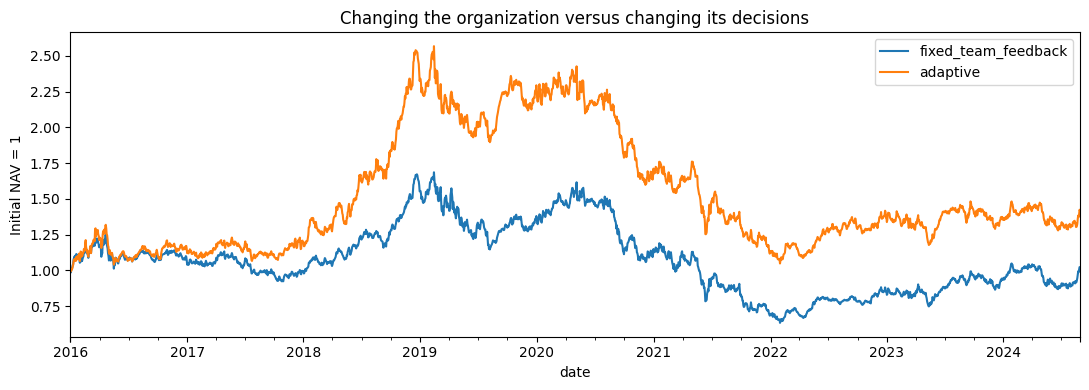

In [ ]:
def topology_table(events):
    return pd.DataFrame([{'asof':e['asof'],'active':', '.join(e['active']),
        'added':', '.join(e.get('plan',{}).get('added',[])),
        'removed':', '.join(e.get('plan',{}).get('removed',[])),
        'requirements':', '.join(e.get('plan',{}).get('required',[]))} for e in events])
topology=topology_table(adaptive['events'])
display(topology.head(15))
topology.to_csv(RESULTS_DIR/'NB04_topology.csv',index=False)
base=pd.read_csv(RESULTS_DIR/'feedback_equity.csv',index_col='date',parse_dates=True).nav
plot_books({'fixed_team_feedback':{'equity':base},'adaptive':adaptive},'Changing the organization versus changing its decisions')

### Code Unit 9 of 10 — Reject invalid and infeasible organizational requests

Two negative cases test the planner's boundaries. A momentum-only team cannot satisfy a low-volatility requirement, and a zero specialist budget cannot acquire even the cheapest relevant capability. Both should fail explicitly. The successful historical plans are also revalidated for coverage and preserved control roles. These checks separate dynamic organization from unconstrained self-modification. A system can be adaptive while still respecting a fixed set of obligations that it is not authorized to remove.

**Expected observation.** The negative examples should raise ValueError and print the expected pass messages. An infeasible capability request is not repaired by dropping an obligation. The notebook makes the boundary visible so future extensions can define an explicit recovery policy.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** What should happen when no feasible constellation can be formed?

In [ ]:
for e in adaptive['events']:
    validate_plan(e['plan'],set(e['plan']['required']))
assert len({tuple(e['active']) for e in adaptive['events']})>1
bad={'agents':['momentum'],'mandatory':MANDATORY}
try:
    validate_plan(bad,{'low_volatility'})
    raise AssertionError('Missing capability was not blocked.')
except ValueError: print('PASS: invalid capability coverage blocked.')
try:
    discover_and_form({'low_volatility'},budget=0)
    raise AssertionError('Infeasible budget was not blocked.')
except ValueError: print('PASS: infeasible budget blocked.')

PASS: invalid capability coverage blocked.
PASS: infeasible budget blocked.


### Code Unit 10 of 10 — Preserve the organizational evaluation and bridge to peers

The final unit reports performance in the same final evaluation window used by NB03 and saves the number of distinct teams formed. These measurements answer different questions: the count shows organizational variation, while the return metrics describe financial outcomes. A large number of teams does not automatically mean better adaptation. The next notebook gives several constellations independent identities and lets them interact. We will move from selecting members within one organization to negotiating complementary services across organizations.

**Expected observation.** The saved summary should distinguish team diversity from investment performance. More configurations can mean useful adaptation or unnecessary churn. NB05 will introduce a separate measurement layer for the contracts and relationships formed between organizations.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Why is the number of distinct teams not a performance metric?

In [ ]:
holdout=adaptive['equity'].loc[view.dates[1764]:]
display(pd.Series(performance(holdout)))
(RESULTS_DIR/'NB04_summary.json').write_text(json.dumps({'different_teams':len({tuple(e['active']) for e in adaptive['events']}),'holdout':performance(holdout)},indent=2))
print('Next: NB05 gives several constellations independent identities and interaction protocols.')

,0
total_return,0.114151
annualized_return,0.036737
annualized_volatility,0.183022
max_drawdown,-0.182772
observations,755.000000


Next: NB05 gives several constellations independent identities and interaction protocols.


<div style="padding:20px;border-left:6px solid #16a34a;background:#f0fdf4;border-radius:10px;color:#0f172a"><b>Conclusion — Capability discovery, team formation, and organizational reconfiguration</b></div>

Notebook 04 has moved adaptation from portfolio decisions to organizational structure. The system now translates observable conditions into capability requirements, discovers feasible combinations of specialists, and chooses a team within a resource budget. The resulting plan identifies members, dependencies, and changes relative to the prior team. Organizational design has become an executable part of the investment process.

This is a meaningful extension beyond the previous loop. In Notebook 03, every specialist continued to work while influence weights changed. Here some specialists can leave the active team and others can enter. The distinction is visible in the event log and topology table. A changed stock selection alone would not establish reconfiguration; a changed membership list with a recorded capability reason does.

The search remains governed. The catalog bounds the capabilities that can be selected, the budget constrains team cost, and coverage rules ensure that the requested analytical functions are present. Review and execution remain mandatory. The malformed-plan and zero-budget examples show that impossible organizational requests are rejected rather than papered over with a plausible explanation. An inability to form a valid team is a state that the system must expose.

The optional model call does not replace these conditions. It chooses among candidate plans through a validated tool interface, and the chosen plan is checked again. The historical experiment uses a deterministic policy so that the organizational effect is reproducible. Neither mode establishes unlimited self-improvement. The system recombines approved capabilities; it does not autonomously invent and validate a new financial model.

Performance evaluation remains necessary but insufficient. A reconfigured team may perform worse because capability tags are crude, environment estimates are noisy, or the policy reacts too late. It may also reduce unnecessary specialist work without improving returns. The resource units provide an initial way to discuss organizational complexity, while the portfolio reports measure financial consequences in the synthetic world. These are related but different dimensions.

The next stage introduces peers. Several constellations will retain their own identities and capability sets. When one team lacks a useful service, it will be able to discover another, negotiate access, receive evidence, and form a temporary alliance. The level of adaptation will therefore expand from the membership of one organization to relationships among several organizations.

For an independent exercise, reduce the specialist budget by one unit and compare the set of feasible teams before running another backtest. This makes the organizational constraint visible without first looking at investment outcomes. Then identify a date where the chosen membership differs and trace the effect through the coordinator's ranking. Preserve the mandatory control roles throughout the exercise.

You should now be able to distinguish three objects: the market observation, the capability requirement inferred from that observation, and the organizational plan formed to satisfy the requirement. This separation is the conceptual bridge to the ecosystem, where a missing capability may be supplied by a different organization rather than another member of the same team.

Before continuing, review the saved artifacts and explain one complete example in your own words. Treat a failed assertion as useful evidence about a broken assumption. Correct that assumption before comparing results. The purpose of this cumulative journey is to understand the mechanism well enough to modify it deliberately, rather than simply collect successful execution messages.

**Continue the journey:** Open NB05 next.

**Implementation references:** [OpenAI function calling](https://developers.openai.com/api/docs/guides/function-calling) · [GPT-5 nano model](https://developers.openai.com/api/docs/models/gpt-5-nano). The introduction and conceptual lesson explain this notebook’s match with the investment banking sequence.

## Live LLM Planning — Structured and Auditable

This section demonstrates genuine LLM participation without installing the OpenAI Python SDK.

The planner now uses the Responses API with **Structured Outputs**. The response schema constrains `choice` to the IDs of the already-feasible candidate plans. GPT-5 nano is also called with minimal reasoning effort and a sufficient output allowance so that the model reliably emits a final selection rather than spending the entire allowance on reasoning.

The architecture remains bounded:

**market observation → required capabilities → feasible plans → LLM or deterministic selector → validated topology → specialists → coordinator → review → execution**

The LLM may choose the topology. It cannot invent a new topology outside the feasible set, remove mandatory roles, bypass the budget, bypass review, or execute trades directly.


### Live-mode preflight

Nothing needs to be installed.

The notebook only verifies that `OPENAI_API_KEY` is available through Colab Secrets. The key is never printed.


In [ ]:
LIVE_LLM=True

_ = api_key()

print('✓ OPENAI_API_KEY is available.')
print('✓ No OpenAI SDK installation is required.')
print('✓ NB04 is ready for the bounded live experiment.')


✓ OPENAI_API_KEY is available.
✓ No OpenAI SDK installation is required.
✓ NB04 is ready for the bounded live experiment.


### Choose dates where the LLM has a real organizational choice

The live demonstration uses a small number of rebalance dates for which more than one feasible team exists. This keeps the exercise inexpensive and makes the selector meaningful.


In [ ]:
BUDGET.used=0
BUDGET.records=[]

eligible_live_dates=[]

for t in schedule:
    env=view.environment(t)
    required=required_capabilities(env)
    _,scores=feedback_influence(shadow,t)
    candidates=discover_and_form(required,scores=scores)

    if len(candidates)>1:
        eligible_live_dates.append(t)

MAX_LIVE_DECISIONS=min(4,len(eligible_live_dates))
LLM_DEMO_DATES=eligible_live_dates[:MAX_LIVE_DECISIONS]

if not LLM_DEMO_DATES:
    raise RuntimeError('No rebalance dates with multiple feasible plans were found.')

# Direct adapter = one uncached API request per LLM decision.
BUDGET.limit=max(BUDGET.limit,len(LLM_DEMO_DATES))

print('LLM demonstration dates:')
for t in LLM_DEMO_DATES:
    print('  ',pd.Timestamp(t).date())

print('Maximum uncached API calls:',len(LLM_DEMO_DATES))


LLM demonstration dates:
   2015-12-31
   2016-01-29
   2016-02-29
   2016-03-31
Maximum uncached API calls: 4


### One-date live smoke test

Before running the multi-date comparison, test one actual LLM planning decision. This is not a separate experiment: it uses the same cache directory, so the comparison cell immediately below reuses this verified result.

A successful result should report `mode = live_llm` on the first run or `mode = cached_llm` on later runs.


In [ ]:
SMOKE_DATE=LLM_DEMO_DATES[0]

_,smoke_scores=feedback_influence(shadow,SMOKE_DATE)

smoke_plan=form_plan(
    view,
    SMOKE_DATE,
    smoke_scores,
    previous=[],
    live=True,
    cache_dir=RESULTS_DIR/'API_CACHE_NB04_LLM'/'llm'
)

print('Date:',pd.Timestamp(SMOKE_DATE).date())
print('Mode:',smoke_plan['mode'])
print('Choice:',smoke_plan['selector_choice'])
print('Team:',smoke_plan['agents'])
print('Explanation:',smoke_plan['selector_explanation'])

assert smoke_plan['mode'] in {'live_llm','cached_llm'}
print('PASS: one real LLM topology selection completed.')


Date: 2015-12-31
Mode: live_llm
Choice: plan_0
Team: ['defensive']
Explanation: Under the observed environment (asof 2015-12-31) with relatively high volatility (0.2696) and modest trend (0.313) and a stress estimate, the required capabilities emphasize low_volatility and resilience. plan_0 uses a single defensive agent, cost 1, utility -0.01, which is the simplest and lowest-cost option that meets the required constraints. Other plans add agents (often more expensive) and yield lower utility. Therefore plan_0 is the most feasible choice given the current environment and requirements.
PASS: one real LLM topology selection completed.


### Deterministic planner versus genuine LLM planner

Both selectors receive the same evidence and the same feasible candidate set.

The deterministic planner follows the ranked fallback. The live planner makes one direct model call and selects one authorized candidate ID. The chosen topology is then reconstructed and validated locally.


In [ ]:
def compare_plan_selectors(view,shadow,dates,cache_dir):
    rows=[]
    det_previous=[]
    llm_previous=[]

    for t in dates:
        _,scores=feedback_influence(shadow,t)

        deterministic_plan=form_plan(
            view,t,scores,
            previous=det_previous,
            live=False,
            cache_dir=cache_dir/'deterministic'
        )

        llm_plan=form_plan(
            view,t,scores,
            previous=llm_previous,
            live=True,
            cache_dir=cache_dir/'llm'
        )

        rows.append({
            'asof':str(pd.Timestamp(t).date()),
            'environment':llm_plan['environment']['estimate'],
            'required':', '.join(llm_plan['required']),
            'deterministic_team':', '.join(deterministic_plan['agents']),
            'llm_team':', '.join(llm_plan['agents']),
            'same_topology':tuple(deterministic_plan['agents'])==tuple(llm_plan['agents']),
            'llm_mode':llm_plan['mode'],
            'llm_choice':llm_plan['selector_choice'],
            'llm_added':', '.join(llm_plan['added']),
            'llm_removed':', '.join(llm_plan['removed']),
            'llm_explanation':llm_plan['selector_explanation']
        })

        det_previous=deterministic_plan['agents']
        llm_previous=llm_plan['agents']

    return pd.DataFrame(rows)

llm_plan_comparison=compare_plan_selectors(
    view,shadow,
    LLM_DEMO_DATES,
    RESULTS_DIR/'API_CACHE_NB04_LLM'
)

display(llm_plan_comparison[
    ['asof','environment','required',
     'deterministic_team','llm_team',
     'same_topology','llm_mode','llm_choice']
])

llm_plan_comparison.to_csv(
    RESULTS_DIR/'NB04_LLM_plan_comparison.csv',
    index=False
)


,asof,environment,required,deterministic_team,llm_team,same_topology,llm_mode,llm_choice
0,2015-12-31,stress,"low_volatility, resilience",defensive,defensive,True,cached_llm,plan_0
1,2016-01-29,stress,"low_volatility, resilience","momentum, defensive",defensive,False,live_llm,plan_1
2,2016-02-29,stress,"low_volatility, resilience","momentum, defensive","momentum, defensive",True,live_llm,plan_0
3,2016-03-31,stress,"low_volatility, resilience","momentum, defensive","momentum, defensive",True,live_llm,plan_0


### Audit: prove whether the LLM actually participated

`live_llm` means a fresh structured Responses API call selected the plan.  
`cached_llm` means the notebook reused a previously verified LLM choice.

The model is not required to disagree with the deterministic planner. Agreement is a valid result. The important architectural distinction is that the selector path is now explicitly recorded and auditable.


In [ ]:
allowed_live_modes={'live_llm','cached_llm'}
observed_modes=set(llm_plan_comparison['llm_mode'])

assert observed_modes <= allowed_live_modes, (
    f'Unexpected selector modes: {observed_modes}'
)

n_same=int(llm_plan_comparison['same_topology'].sum())
n_different=int((~llm_plan_comparison['same_topology']).sum())

print('PASS: LLM selector path verified.')
print('Fresh API calls recorded:',len(BUDGET.records))
print('Same topology:',n_same)
print('Different topology:',n_different)

if n_different==0:
    print('The LLM genuinely participated but converged on the deterministic topology.')
else:
    print('The LLM selected a different valid topology on at least one date.')


PASS: LLM selector path verified.
Fresh API calls recorded: 4
Same topology: 3
Different topology: 1
The LLM selected a different valid topology on at least one date.


### Propagate the verified LLM topology into the trading system

The short trading demonstration reuses the **same LLM cache** created above. No second set of model calls is necessary.

The selected specialists then enter the unchanged governance pipeline:

**specialists → coordinator → independent review → simulated execution**


In [ ]:
adaptive_llm_demo=run_book(
    view,
    adaptive_policy(
        view,shadow,
        live_mode=True,
        cache_dir=RESULTS_DIR/'API_CACHE_NB04_LLM'/'llm'
    ),
    'adaptive_llm_demo',
    dates=LLM_DEMO_DATES
)

topology_llm_demo=topology_table(adaptive_llm_demo['events'])
display(topology_llm_demo)

book_modes={e['plan']['mode'] for e in adaptive_llm_demo['events']}
assert book_modes <= {'live_llm','cached_llm'}, book_modes

save_book(adaptive_llm_demo,RESULTS_DIR)

topology_llm_demo.to_csv(
    RESULTS_DIR/'NB04_topology_llm_demo.csv',
    index=False
)

print('PASS: verified LLM planning choices propagated into the trading architecture.')


,asof,active,added,removed,requirements
0,2015-12-31,defensive,defensive,,"low_volatility, resilience"
1,2016-01-29,defensive,,,"low_volatility, resilience"
2,2016-02-29,"momentum, defensive",momentum,,"low_volatility, resilience"
3,2016-03-31,"momentum, defensive",,,"low_volatility, resilience"


PASS: verified LLM planning choices propagated into the trading architecture.


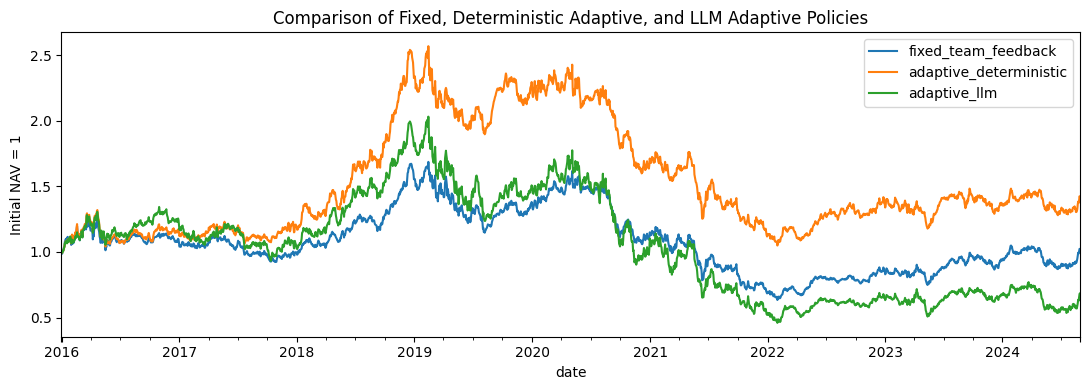

In [ ]:
plot_books(
    {
        'fixed_team_feedback': {'equity': base},
        'adaptive_deterministic': adaptive,
        'adaptive_llm': adaptive_llm_demo
    },
    'Comparison of Fixed, Deterministic Adaptive, and LLM Adaptive Policies'
)

### Interpretation

NB04 now has two clean experiments.

**Full-history experiment:** deterministic and reproducible self-adaptation.

**Bounded live experiment:** genuine LLM participation in choosing among feasible organizational topologies.

The LLM helps choose the organization. It does not define the governance rules that determine whether that organization is valid.
